# Lorenz-96 forcing ensemble: example

Integrates saved reduced-order models along a subset of the testing tracers of the full run, and reproduces its per-tracer figures. The example contains no training data, so no fitting is performed, and it requires no data outside this directory.

The state is signed, z = x - F, so the error tolerance is absolute and the positivity projection does not apply.

In [1]:
import os
import sys
from types import SimpleNamespace

sys.path.insert(0, os.path.abspath("../../../"))

import numpy as np

from src import plots as P
from src.cluster import Cluster
from src.config import SUBSTEPS, combo_stem
from src.data import load_trajectories
from src.evaluate import evaluate
from src.lorenz96 import Lorenz96Network
from src.pipeline import case_config
from src.rom import EnsembleROM

%matplotlib inline

CASE = "lorenz96"
SWEEP_DIR = "sweep"
FIG_DIR = "figures"
POSITIVITY = False

## Load the example

`tracers.npz` holds the parameter trajectory of each included tracer, its global id, its position in the testing dataset of the full run, and the hydrodynamic time step. `feature_matrix_test.npy` holds the full-order trajectories of the same tracers, from which the initial states are taken.

The figure functions read only the network, the QoI indices, the time step and the global ids from the run context, so that subset is assembled here.

In [2]:
cfg = case_config(CASE, ".", n_workers=os.cpu_count() or 1)

with np.load("tracers.npz") as z:
    tracers = z["tracers"]
    global_ids = z["global_ids"]
    positions = z["source_positions"]
    dt_hydro = float(z["dt_hydro"])
    n_state = int(z["n_species"])

net = Lorenz96Network(n_state)
qoi_indices = np.asarray(cfg.qoi, dtype=int)
qoi = [net.species[j] for j in qoi_indices]

t_foms, y_foms, x_eqs = load_trajectories("feature_matrix_test.npy", len(global_ids), n_state)
ctx = SimpleNamespace(net=net, qoi_indices=qoi_indices, dt_hydro=dt_hydro, test_indices=global_ids)

print(f"{len(global_ids)} forcings | N={n_state} | qoi={qoi}")
print("positions: ", positions.tolist())
print("global ids:", global_ids.tolist())

9 forcings | N=100 | qoi=['x0', 'x25', 'x50', 'x75']
positions:  [0, 1, 2, 3, 4, 5, 6, 7, 45]
global ids: [168, 129, 154, 105, 158, 11, 142, 43, 194]


<string>:29: RuntimeWarning: error_norm='absolute': rank proxy disabled, so the rank walk re-scores every rank from r0+1 and the build is slower.


## Evaluate the models

Each included model is integrated along every included tracer. The table gives the relative L2-in-time error on each QoI, which equals the corresponding entry of the per-tracer tables of the full run.

In [3]:
MODELS = [(0.02, 1e-3)]   # (tau, eta) of each included model


def load_model(tau, eta):
    stem = combo_stem(tau, eta)
    cl = Cluster.load(f"{SWEEP_DIR}/cluster_{stem}.npz")
    return EnsembleROM.load(f"{SWEEP_DIR}/ensemble_{stem}.npz", cl, net).precompute_B_structure()


for tau, eta in MODELS:
    ens = load_model(tau, eta)
    res = evaluate(ens, tracers, x_eqs, t_foms, y_foms, qoi_indices, qoi, dt_hydro, cfg.replace(tau_split=tau, eta=eta, positivity=POSITIVITY), verbose=False)
    print(f"\n{combo_stem(tau, eta)}: {res['n_valid']}/{res['n_tracers']} complete, {len(ens.roms)} clusters, mean basis size {ens.mean_rank():.2f}")
    print(f"{'position':>9} {'global id':>9}  " + "  ".join(f"{q:>9}" for q in qoi))
    for row, k in enumerate(res["valid_idx"]):
        print(f"{positions[k]:>9} {global_ids[k]:>9}  " + "  ".join(f"{res['per_tracer']['l2-in-time'][q][row]:9.2e}" for q in qoi))

Loaded sweep/cluster_tol0.02_eta1e-3.npz  (k=365)



tol0.02_eta1e-3: 9/9 complete, 365 clusters, mean basis size 5.46
 position global id         x0        x25        x50        x75
        0       168   2.16e-02   1.75e-02   1.11e-02   1.28e-02
        1       129   6.28e-02   3.77e-02   2.82e-02   3.32e-02
        2       154   1.62e-02   1.07e-02   7.98e-03   6.34e-03
        3       105   6.78e-02   4.30e-02   3.44e-02   2.17e-02
        4       158   3.82e-02   3.05e-02   2.01e-02   1.68e-02
        5        11   8.29e-04   3.51e-03   2.73e-04   2.70e-04
        6       142   2.12e-02   2.84e-02   1.52e-02   1.03e-02
        7        43   4.74e-03   6.55e-04   2.05e-04   1.86e-04
       45       194   1.25e-01   1.10e-01   7.47e-02   7.91e-02


## Figures

One trajectory, banded by cluster. Each band spans consecutive intervals routed to the same cluster. The reduced model works in z = x - F, so the curves are shifted back to x. The single-basis baseline of the full run is omitted, since fitting it requires the training data.

Loaded sweep/cluster_tol0.02_eta1e-3.npz  (k=365)


F = 2.44 | 97 clusters visited | tau_split = 0.02, eta = 0.001


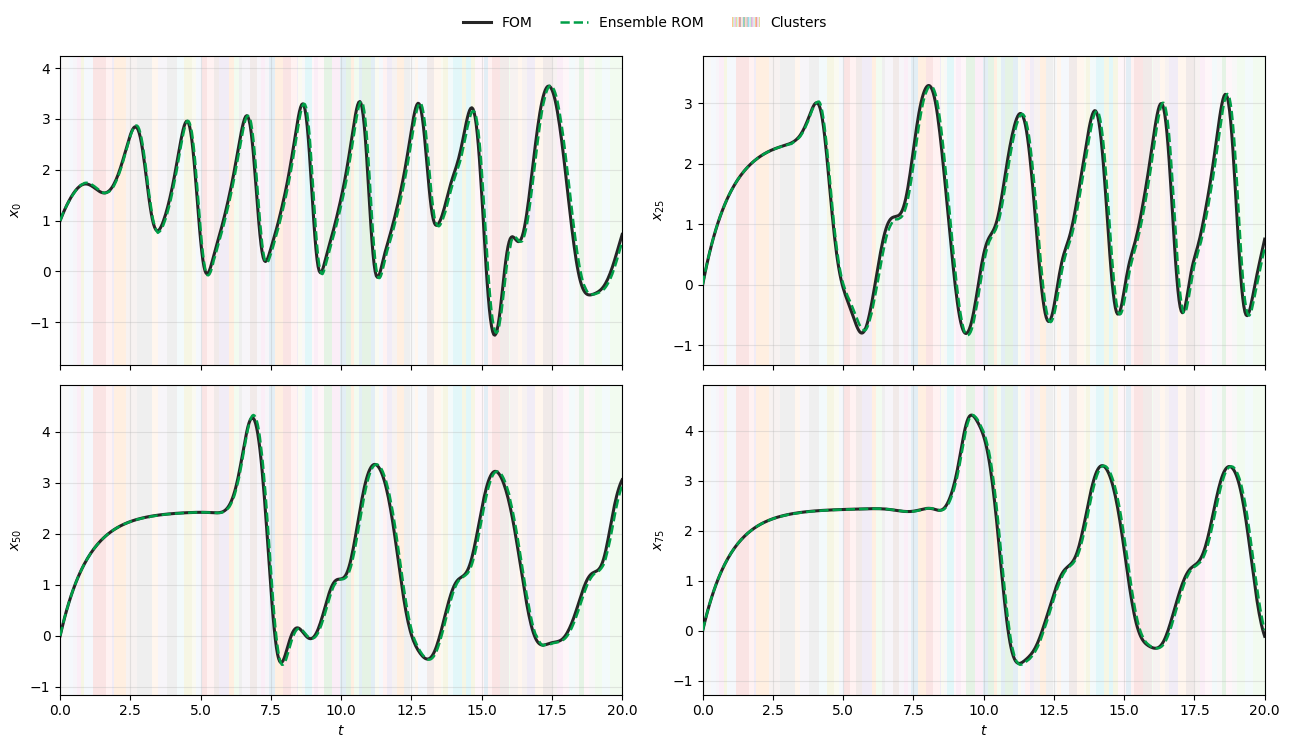

In [4]:
TAU, ETA = 0.02, 1e-3
TRACER = 45                       # position within the testing dataset of the full run; the forcing nearest 2.45

k = int(np.flatnonzero(positions == TRACER)[0])
ens = load_model(TAU, ETA)
pt_k = np.asarray(tracers[k], dtype=np.float64)
F = float(pt_k[0, 0])
knots = dt_hydro * np.arange(pt_k.shape[0])

z0 = np.asarray(y_foms[k])[:, 0]
_, z_rom, route_k, info_rom = ens.solve_tracer(pt_k, z0, dt_hydro, cfg.atol, cfg.rtol, t_eval=knots, positivity=False, method=cfg.ode_method)

series = {"reference": np.asarray(y_foms[k])[:, ::SUBSTEPS] + F, "clustered": None if info_rom is not None else z_rom + F}
figT, axesT = P.trajectory_panel(knots, series, route_k, list(qoi_indices))

os.makedirs(FIG_DIR, exist_ok=True)
figT.savefig(f"{FIG_DIR}/trajectory.pdf", dpi=200)
print(f"F = {F:.3g} | {np.unique(route_k).size} clusters visited | tau_split = {TAU}, eta = {ETA:g}")